haio


In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [17]:
df=pd.read_csv('data\stud.csv')

In [19]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


NO null values

In [21]:
df.shape

(1000, 8)

In [24]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [25]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

No missing values

In [27]:
df.duplicated().sum()

0

No duplicate values

In [29]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math_score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading_score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing_score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


there are 3 numerical columns

>mean of 3 columns are close to each other 

>nearly students are abive mean marks

>all SD are around 15

> there is minumum of 0 marks in mathscore and maxof 100 in all 3

In [36]:
print('categeries in gender column:',df['gender'].unique())
print('categeries in race column:',df['race_ethnicity'].unique())
print('categeries in parental_level_of_education column:',df['parental_level_of_education'].unique())
print('categeries in lunch column:',df['lunch'].unique())
print('categeries in test_preparation_course column:',df['test_preparation_course'].unique())

categeries in gender column: ['female' 'male']
categeries in race column: ['group B' 'group C' 'group A' 'group D' 'group E']
categeries in parental_level_of_education column: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categeries in lunch column: ['standard' 'free/reduced']
categeries in test_preparation_course column: ['none' 'completed']


In [43]:
# defining numerical categorical feautures
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O' ]
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O' ]

print('we have {} numerical features : {}'.format(len(numeric_features),numeric_features))
print('we have {} categorical features : {}'.format(len(categorical_features),categorical_features))

we have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
we have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [44]:
df['total']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total']/3

<Axes: xlabel='average', ylabel='Count'>

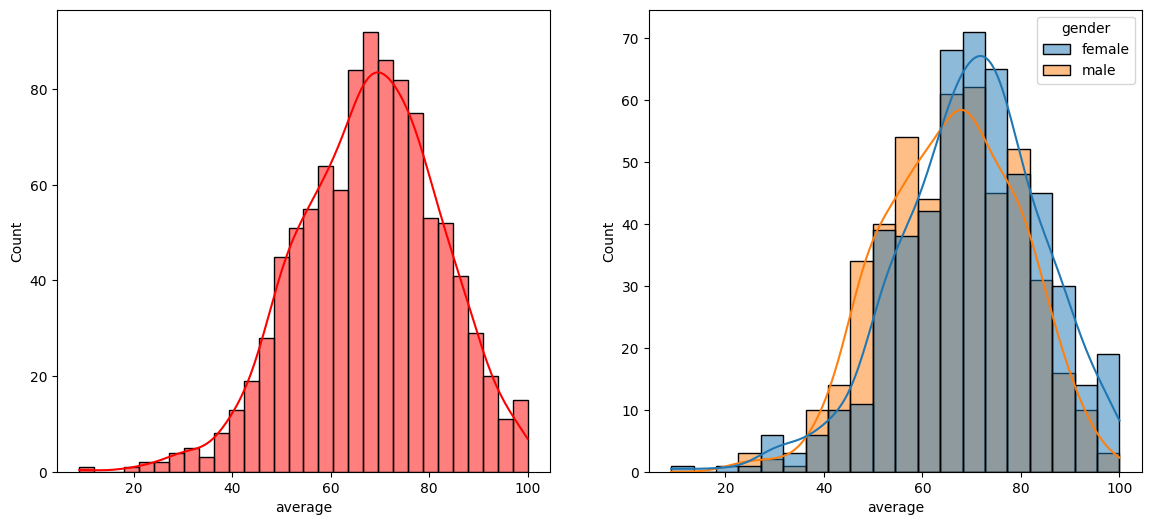

In [75]:
fig,axis=plt.subplots(1,2,figsize=(14,6))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='red')
plt.subplot(122)
sns.histplot(data=df,x='average',bins=20,kde=True,hue='gender')

>female students tend perform better than male students

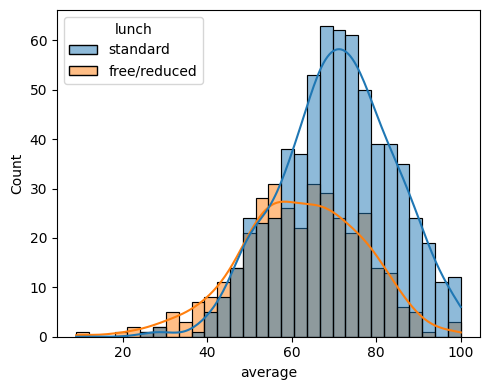

In [90]:
fig,axis=plt.subplots(1,1,figsize=(5,4))
sns.histplot(data=df,x='average',bins=30,hue='lunch',color='blue',kde=True)

plt.tight_layout()
plt.show()

>students having standard lunch have good performance

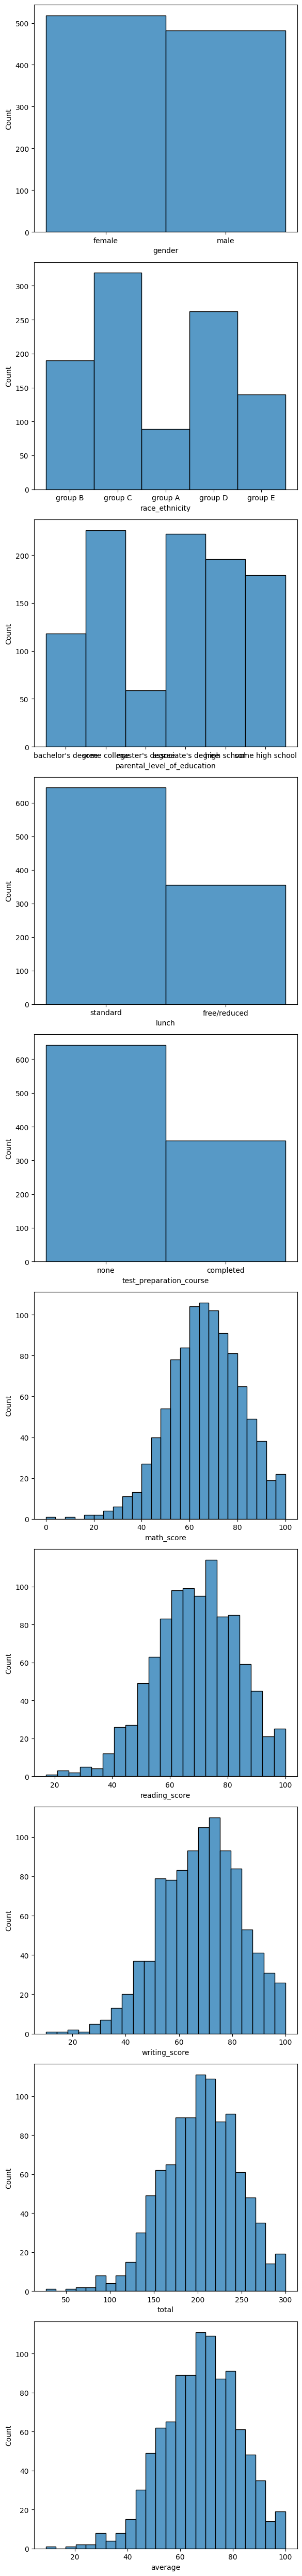

In [110]:
cols=1
rows=len(df.columns)

fig,axis=plt.subplots(rows,cols,figsize=(6,5*rows))
axis=axis.flatten()

for i,col in enumerate(df.columns):
    sns.histplot(data=df,x=col,ax=axis[i])

plt.tight_layout()
plt.show()

>surprisingly students who didnot have any test preperation course performed better 